
--- Molecular Structure Validation ---
Total O atoms: 17066
Total H atoms: 34132
Valid H2O molecules found (O with 2 H in range): 16493
Oxygen atoms with incorrect H count: 573


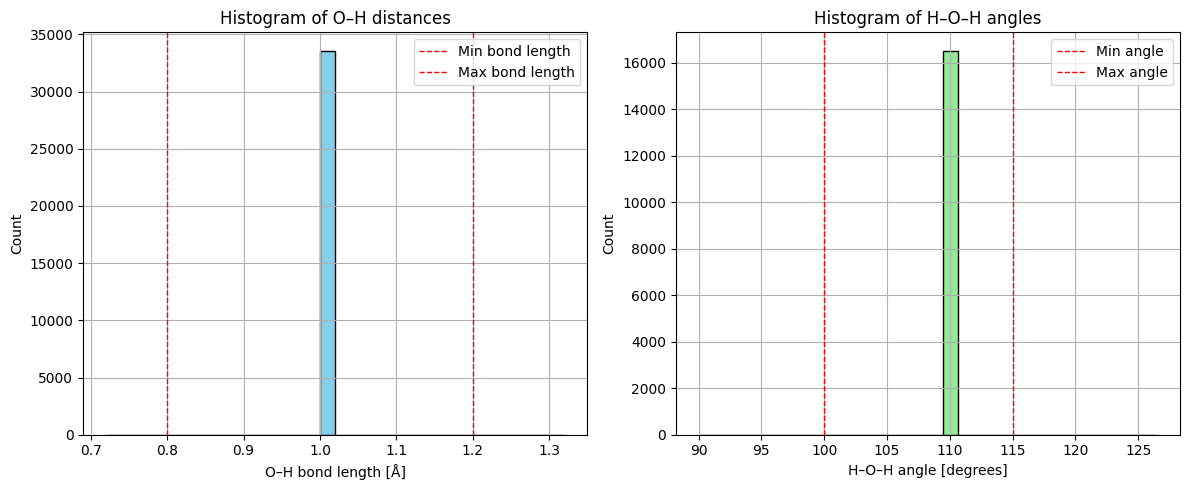


--- Overall System Checks ---
❌ Some structural inconsistencies found. Review warnings above.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


lammps_data_file = "/mnt/c/Users/vbarv/Desktop/vns/course/project/lammps/data/water_equilibrated_for_droplet.data"
r_min, r_max = 0.8, 1.2 # Expected O-H bond length range (Å)
angle_min, angle_max = 100, 115 # Expected H-O-H angle range (degrees)


def read_lammps_data_atoms(filepath):
    """
    Reads atom symbols and coordinates from a LAMMPS data file.
    Assumes 'Atoms' section is in 'full' atom_style
    """
    symbols = []
    coords = []
    n_atoms = 0
    in_atoms_section = False

    with open(filepath, 'r') as f:
        for line in f:
            if "atoms" in line and not in_atoms_section:
                try:
                    n_atoms = int(line.split()[0])
                except ValueError:
                    continue # Skip if 'atoms' is not preceded by a number
            
            if line.strip().startswith("Atoms"):
                in_atoms_section = True
                f.readline() # Read and discard the blank line
                continue

            if in_atoms_section:
                parts = line.strip().split()
                if not parts: # Empty line signals end of section
                    break
                
                # For SPC/E water: type 1 is Oxygen, type 2 is Hydrogen
                atom_type_id = int(parts[2])
                if atom_type_id == 1:
                    symbols.append("O")
                elif atom_type_id == 2:
                    symbols.append("H")
                else:
                    symbols.append("UNKNOWN") # Handle unexpected types

                coords.append([float(parts[4]), float(parts[5]), float(parts[6])])
            
            if n_atoms > 0 and len(coords) == n_atoms:
                break

    if len(coords) != n_atoms:
        print(f"WARNING: Expected {n_atoms} atoms but found {len(coords)}")

    return n_atoms, np.array(coords), symbols


# Read atom data from the LAMMPS data file
n_atoms, coords, symbols = read_lammps_data_atoms(lammps_data_file)

oxygen_indices = [i for i, s in enumerate(symbols) if s.upper() == "O"]
hydrogen_indices = [i for i, s in enumerate(symbols) if s.upper() == "H"]

valid_molecules = 0
total_oxygens = len(oxygen_indices)
total_hydrogens = len(hydrogen_indices)
distances_oh = [] # Stores O-H bond lengths
angles_hoh = []   # Stores H-O-H angles

# To track atom connectivity
o_connectivity = {o_idx: 0 for o_idx in oxygen_indices}
h_connectivity = {h_idx: 0 for h_idx in hydrogen_indices}

print("\n--- Molecular Structure Validation ---")
# Iterate through oxygen atoms to find connected hydrogens
for oi in oxygen_indices:
    ox_coord = coords[oi]
    connected_h_indices = []
    
    for hi in hydrogen_indices:
        h_coord = coords[hi]
        r_oh = np.linalg.norm(h_coord - ox_coord)
        
        if r_min <= r_oh <= r_max:
            connected_h_indices.append(hi)
            distances_oh.append(r_oh)
            o_connectivity[oi] += 1
            h_connectivity[hi] += 1

    if len(connected_h_indices) == 2:
        valid_molecules += 1
        h1_idx, h2_idx = connected_h_indices[0], connected_h_indices[1]
        
        # Calculate H-O-H angle
        vec_oh1 = coords[h1_idx] - ox_coord
        vec_oh2 = coords[h2_idx] - ox_coord
        
        # Normalize vectors
        norm_oh1 = np.linalg.norm(vec_oh1)
        norm_oh2 = np.linalg.norm(vec_oh2)
        
        if norm_oh1 > 0 and norm_oh2 > 0:
            dot_product = np.dot(vec_oh1, vec_oh2)
            angle_rad = np.arccos(np.clip(dot_product / (norm_oh1 * norm_oh2), -1.0, 1.0)) # Clip to avoid floating point errors
            angle_deg = np.degrees(angle_rad)
            angles_hoh.append(angle_deg)

print(f"Total O atoms: {total_oxygens}")
print(f"Total H atoms: {total_hydrogens}")
print(f"Valid H2O molecules found (O with 2 H in range): {valid_molecules}")
print(f"Oxygen atoms with incorrect H count: {total_oxygens - valid_molecules}")

    
# --- Plotting Histograms ---
plt.figure(figsize=(12, 5))

# O-H bond length histogram
plt.subplot(1, 2, 1)
plt.hist(distances_oh, bins=30, color='skyblue', edgecolor='black', range=(r_min*0.9, r_max*1.1))
plt.xlabel("O–H bond length [Å]")
plt.ylabel("Count")
plt.title("Histogram of O–H distances")
plt.axvline(r_min, color='red', linestyle='dashed', linewidth=1, label='Min bond length')
plt.axvline(r_max, color='red', linestyle='dashed', linewidth=1, label='Max bond length')
plt.grid(True)
plt.legend()

# H-O-H angle histogram
plt.subplot(1, 2, 2)
if angles_hoh: # Only plot if there are angles to plot
    plt.hist(angles_hoh, bins=30, color='lightgreen', edgecolor='black', range=(angle_min*0.9, angle_max*1.1))
    plt.xlabel("H–O–H angle [degrees]")
    plt.ylabel("Count")
    plt.title("Histogram of H–O–H angles")
    plt.axvline(angle_min, color='red', linestyle='dashed', linewidth=1, label='Min angle')
    plt.axvline(angle_max, color='red', linestyle='dashed', linewidth=1, label='Max angle')
    plt.grid(True)
    plt.legend()
else:
    plt.text(0.5, 0.5, "No H-O-H angles to plot (0 valid molecules)", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

# Assuming SPCE water, each molecule has 3 atoms, 2 bonds, 1 angle
expected_total_atoms = valid_molecules * 3
expected_total_bonds = valid_molecules * 2
expected_total_angles = valid_molecules * 1

if n_atoms != expected_total_atoms:
    print(f"WARNING: Total atoms in file ({n_atoms}) does not match expected from valid molecules ({expected_total_atoms}).")